In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_processing import (
    create_lag_features,
    standardize_X,
    standardize_Y,
    create_XY
)

from src.QNN_algo import weatherQNN
from src.trainer import QNNTrainer

file_path = '../data/boston_weather_data_2.csv'
df = pd.read_csv(file_path)

In [3]:
#experiment parameters
candidate_features = ['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']

#select features and lag period for QML
available_features = ['hum', 'uvi', 'tavg', 'wspd']
# available_features: the features we select

LAG_WINDOW = 3

ENTANGLEMENT_TYPE = 2

DEPTH = 3
LEARNING_RATE = 0.1
BATCH_SIZE = 10
VALIDATION_SPLIT = 0.1
EPOCHS = 30

In [4]:
df['target_tomorrow_tavg'] = df['tavg'].shift(-1)

featureCorrelations = df[candidate_features].corrwith(df['target_tomorrow_tavg'], method = 'pearson')
print("the correlation of features with tmr's tavg")
print(featureCorrelations)
print('\n')

feature_corr_matrix = df[candidate_features].corr(method='pearson')

print("the correlation between each feature:")
print(feature_corr_matrix[['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']])

the correlation of features with tmr's tavg
hum     0.889483
uvi     0.787512
tavg    0.958117
wspd   -0.603002
wdir   -0.209369
pres    0.116534
prcp   -0.021052
dtype: float64


the correlation between each feature:
           hum       uvi      tavg      wspd      wdir      pres      prcp
hum   1.000000  0.729129  0.930165 -0.507044 -0.205901 -0.084722  0.129220
uvi   0.729129  1.000000  0.788113 -0.422559 -0.040162  0.082045 -0.166763
tavg  0.930165  0.788113  1.000000 -0.542671 -0.181006 -0.015993  0.032974
wspd -0.507044 -0.422559 -0.542671  1.000000  0.230360 -0.412289  0.087869
wdir -0.205901 -0.040162 -0.181006  0.230360  1.000000 -0.146881 -0.258837
pres -0.084722  0.082045 -0.015993 -0.412289 -0.146881  1.000000 -0.267582
prcp  0.129220 -0.166763  0.032974  0.087869 -0.258837 -0.267582  1.000000


In [5]:


X, Y = create_XY(df, available_features, lag_window = LAG_WINDOW)

correlations = X.corrwith(Y, method = 'pearson')
print("the correlation of each feature_lag with tmr's temp:")
print(correlations)
print(f"# of rows of the dataset: {len(X)}\n")


# candidate_features2 = ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres']
# df_clean2 = df.dropna(subset = candidate_features2 + ['target_tomorrow_tavg'])

# correlations2 = df_clean2[candidate_features2].corrwith(df_clean2['target_tomorrow_tavg'], method = 'pearson')
# print("the correlation of each feature(without wdir) with tmr's temp:")
# print(correlations2)
# print(f"# of rows of the dataset: {len(df_clean2)}")

the correlation of each feature_lag with tmr's temp:
hum_lag1     0.840152
hum_lag2     0.821923
hum_lag3     0.822063
uvi_lag1     0.796445
uvi_lag2     0.800482
uvi_lag3     0.801211
tavg_lag1    0.917712
tavg_lag2    0.902678
tavg_lag3    0.898205
wspd_lag1   -0.574546
wspd_lag2   -0.550518
wspd_lag3   -0.541098
dtype: float64
# of rows of the dataset: 665



to what extend the synchronous trands of Tavg and Humidity match:


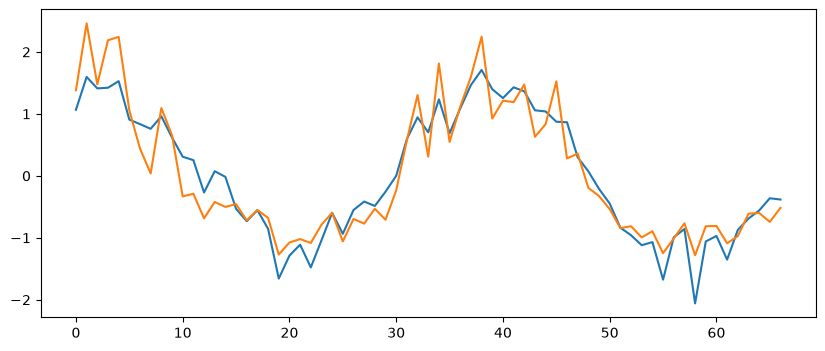

In [6]:
#this is just a demonstration of the trends of Tavg and Humidity
data = pd.read_csv("../data/boston_weather_data_2.csv")
temp = data[["tavg", "hum"]].values

tavg_col = temp[:, 0]
hum_col = temp[:, 1]

tavg_mean = np.mean(tavg_col)
hum_mean = np.mean(hum_col)

tavg_stdev = np.std(tavg_col)
hum_stdev = np.std(hum_col)

tavg_zscr = (temp[:, 0] - tavg_mean) / tavg_stdev
hum_zscr = (temp[:, 1] - hum_mean) / hum_stdev

Z = np.column_stack([tavg_zscr, hum_zscr])

step = 10
Z_plot = Z[::step]

plt.figure(figsize = (10, 4))
plt.plot(Z_plot[:,0], label = 'Tavg')
plt.plot(Z_plot[:,1], label = 'Humidity')

print("to what extend the synchronous trands of Tavg and Humidity match:")
plt.show()

In [7]:
#standardization
X_angle, means, stds, alphas = standardize_X(X, X.columns)

Y_zscr, Y_mean, Y_std = standardize_Y(Y)

print(X_angle.shape)
print(Y_zscr.shape)

(665, 12)
(665,)


In [8]:
#create qnn circuit
model = weatherQNN(
    num_qubits = X_angle.shape[1],
    depth = DEPTH,
    entanglement_type = ENTANGLEMENT_TYPE
)

In [9]:
#train the model
trainer = QNNTrainer(
    model,
    learning_rate = LEARNING_RATE,
    batch_size = BATCH_SIZE,
    validation_split = VALIDATION_SPLIT,
    epochs = EPOCHS
)

weights, history = trainer.train(
    X_angle,
    Y_zscr
)

0.13163446461466366
Epoch 0: train=0.912045, val=0.517526
0.10161516892326151
Epoch 1: train=0.911666, val=0.519137
0.09962679156626683
Epoch 2: train=0.911315, val=0.517134
0.17332137552595142
Epoch 3: train=0.910998, val=0.512866
0.13863634028171606
Epoch 4: train=0.910242, val=0.515618
0.13808452753921066
Epoch 5: train=0.909557, val=0.518826
0.11853845745130205
Epoch 6: train=0.908817, val=0.519981
0.076925970546586
Epoch 7: train=0.908786, val=0.518775
0.07661827346732897
Epoch 8: train=0.908358, val=0.518273
0.12532145915523357
Epoch 9: train=0.907587, val=0.517456
0.13948166809741197
Epoch 10: train=0.906662, val=0.518289
0.16115454402068474
Epoch 11: train=0.905772, val=0.521655
0.356517920641324
Epoch 12: train=0.904621, val=0.532359
0.10021817941361487
Epoch 13: train=0.904501, val=0.529870
0.18265031200832965
Epoch 14: train=0.903868, val=0.526177
0.12973775418879557
Epoch 15: train=0.903038, val=0.527527
0.08589400565353189
Epoch 16: train=0.902676, val=0.528989
0.091429880

{'train_loss': [np.float64(0.9120447840709233), np.float64(0.9116661165360035), np.float64(0.9113151289742684), np.float64(0.910997698017265), np.float64(0.9102421613363207), np.float64(0.9095571078486961), np.float64(0.9088168610570279), np.float64(0.908786040828335), np.float64(0.908357712054781), np.float64(0.9075868844150063), np.float64(0.9066620468641824), np.float64(0.9057721883290912), np.float64(0.9046209787310032), np.float64(0.9045006566291364), np.float64(0.903868202502682), np.float64(0.9030381211184567), np.float64(0.9026755070592614), np.float64(0.9021744270162632), np.float64(0.9013458510746571), np.float64(0.90093475341604), np.float64(0.9005608994119495), np.float64(0.8998165562561631), np.float64(0.8995689916161083), np.float64(0.899279795428237), np.float64(0.899159976080961), np.float64(0.8991365581646369), np.float64(0.8985096861552503), np.float64(0.8978360382923003), np.float64(0.8965361277568284), np.float64(0.8957688203347121)], 'val_loss': [np.float64(0.51752

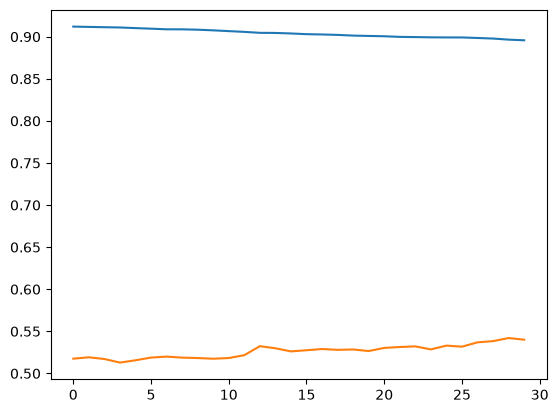

In [10]:
#graph
plt.plot(history['train_loss'])
plt.plot(history['val_loss'])

print(history)